In [174]:
import pandas as pd


In [175]:
beer_df = pd.read_excel('/Users/nestocr/Documents/DataAnalytics_BootCamp/da-capstone-project-dayane-ernesto/Ernestos_finds/WHO Data/economic-aspects/data/Average price 500 mls Beer in US$MOD.xlsx')
tax_df = pd.read_excel('/Users/nestocr/Documents/DataAnalytics_BootCamp/da-capstone-project-dayane-ernesto/Ernestos_finds/WHO Data/economic-aspects/data/Alcoholic excise tax revenue as a per cent of government revenueMOD.xlsx')
expenditure_df = pd.read_excel('/Users/nestocr/Documents/DataAnalytics_BootCamp/da-capstone-project-dayane-ernesto/Ernestos_finds/WHO Data/economic-aspects/data/Alcohol expenditure as a per cent of total household expenditureMOD.xlsx')

print("--- BEER PRICE DATA ---")
print(beer_df.head())
print(beer_df.info())

print("\n--- TAX REVENUE DATA ---")
print(tax_df.head())

print("\n--- HOUSEHOLD EXPENDITURE DATA ---")
print(expenditure_df.head())


--- BEER PRICE DATA ---
  SpatialDimensionValueCode  Year  Avg. Price in US$/500 ml Beer
0                       COD  2016                           0.51
1                       MWI  2016                           1.17
2                       MLI  2016                           0.87
3                       ZMB  2016                           1.08
4                       ZWE  2016                           1.08
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 3 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   SpatialDimensionValueCode      167 non-null    object 
 1   Year                           167 non-null    int64  
 2   Avg. Price in US$/500 ml Beer  167 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 4.0+ KB
None

--- TAX REVENUE DATA ---
  SpatialDimensionValueCode  Year  % of Government Revenue on Alcohol Tax. 
0            

In [176]:
tax_df['SpatialDimensionValueCode'].unique()

array(['ESP', 'FIN', 'GBR', 'EST', 'ISL', 'ZAF', 'SWE', 'NOR', 'POL',
       'JPN', 'UGA', 'NZL', 'SGP', 'IRL', 'MLI', 'MUS', 'LKA', 'DOM',
       'MEX', 'CAN', 'MYS', 'DEU', 'CHE', 'MNG', 'KOR', 'DNK', 'TUR',
       'AUT', 'FRA', 'IND', 'ZWE', 'NPL', 'AUS', 'BEL', 'NLD', 'PRT',
       'USA', 'ITA', 'LUX'], dtype=object)

In [177]:
# 1. Create a "Translation Key" (ISO code to Name)
iso_map = {
    'ALB': 'Albania', 'DEU': 'Germany', 
    'IRL': 'Ireland', 'ITA': 'Italy', 'CZE': 'Czechia'
}

# 2. Rename & Map Beer Data
beer_clean = beer_df.rename(columns={
    'SpatialDimensionValueCode': 'iso_code', 
    'Year': 'year', 
    'Avg. Price in US$/500 ml Beer': 'beer_price_usd'
})
beer_clean['location'] = beer_clean['iso_code'].map(iso_map)

# 3. Rename & Map Tax Data (Watch for that dot/space!)
tax_clean = tax_df.rename(columns={
    'SpatialDimensionValueCode': 'iso_code', 
    'Year': 'year', 
    '% of Government Revenue on Alcohol Tax. ': 'tax_revenue_pct'
})
tax_clean['location'] = tax_clean['iso_code'].map(iso_map)

# 4. Rename & Map Expenditure Data
exp_clean = expenditure_df.rename(columns={
    'Country': 'iso_code', 
    'TimeDim': 'year', 
    '% of alohol expenditure per household': 'household_exp_pct'
})
exp_clean['location'] = exp_clean['iso_code'].map(iso_map)

# Filter for only our "Champion" countries
beer_clean = beer_clean.dropna(subset=['location'])
tax_clean = tax_clean.dropna(subset=['location'])
exp_clean = exp_clean.dropna(subset=['location'])

In [178]:
beer_clean.head(10)

,iso_code,year,beer_price_usd,location
12,CZE,2016,0.86,Czechia
29,IRL,2016,4.41,Ireland
69,ITA,2016,4.56,Italy
134,ALB,2016,0.71,Albania
135,DEU,2016,2.65,Germany


In [179]:
exp_clean.drop(columns=['iso_code'])

,year,household_exp_pct,location
23,1990,1.1,Italy
24,2005,0.8,Italy
25,2007,0.7,Italy
55,2015,1.3,Albania
58,2016,1.5,Czechia
78,1996,0.9,Italy
79,1997,0.8,Italy
113,2012,1.1,Czechia
122,2015,1.6,Italy
150,1995,0.8,Italy


In [180]:
tax_clean.drop(columns=['iso_code'])

,year,tax_revenue_pct,location
22,2014,0.6,Ireland
43,2013,0.6,Germany
45,2013,0.6,Ireland
69,2012,0.6,Germany
70,2012,0.5,Ireland
94,2011,0.7,Germany
96,2011,0.5,Ireland
118,2010,0.5,Ireland
133,2009,1.8,Ireland
262,1996,5.0,Ireland


In [181]:
beer_clean.drop(columns=['iso_code'])

,year,beer_price_usd,location
12,2016,0.86,Czechia
29,2016,4.41,Ireland
69,2016,4.56,Italy
134,2016,0.71,Albania
135,2016,2.65,Germany


In [182]:
beer_clean= beer_clean[['location','year','beer_price_usd']]
beer_clean

,location,year,beer_price_usd
12,Czechia,2016,0.86
29,Ireland,2016,4.41
69,Italy,2016,4.56
134,Albania,2016,0.71
135,Germany,2016,2.65


In [183]:
tax_clean = tax_clean[['location', 'year','tax_revenue_pct']]
tax_clean

,location,year,tax_revenue_pct
22,Ireland,2014,0.6
43,Germany,2013,0.6
45,Ireland,2013,0.6
69,Germany,2012,0.6
70,Ireland,2012,0.5
94,Germany,2011,0.7
96,Ireland,2011,0.5
118,Ireland,2010,0.5
133,Ireland,2009,1.8
262,Ireland,1996,5.0


In [184]:
beer_clean.reset_index(drop=True, inplace=True)
beer_clean

,location,year,beer_price_usd
0,Czechia,2016,0.86
1,Ireland,2016,4.41
2,Italy,2016,4.56
3,Albania,2016,0.71
4,Germany,2016,2.65


In [185]:
tax_clean.reset_index(drop=True, inplace=True)

In [186]:
exp_clean = expenditure_df.rename(columns={
    'Country': 'iso_code', 
    'TimeDim': 'year', 
    '% of alohol expenditure per household': 'household_exp_pct'
})
exp_clean['location'] = exp_clean['iso_code'].map(iso_map)


In [187]:
exp_clean = exp_clean.dropna(subset=['location'])


In [188]:
exp_clean.drop(columns=['iso_code'], inplace=True)
exp_clean

,year,household_exp_pct,location
23,1990,1.1,Italy
24,2005,0.8,Italy
25,2007,0.7,Italy
55,2015,1.3,Albania
58,2016,1.5,Czechia
78,1996,0.9,Italy
79,1997,0.8,Italy
113,2012,1.1,Czechia
122,2015,1.6,Italy
150,1995,0.8,Italy


In [189]:
exp_clean = exp_clean[['location', 'year', 'household_exp_pct']]
exp_clean

,location,year,household_exp_pct
23,Italy,1990,1.1
24,Italy,2005,0.8
25,Italy,2007,0.7
55,Albania,2015,1.3
58,Czechia,2016,1.5
78,Italy,1996,0.9
79,Italy,1997,0.8
113,Czechia,2012,1.1
122,Italy,2015,1.6
150,Italy,1995,0.8


In [190]:
beer_profile = beer_clean.sort_values('year').groupby('location').tail(1)

In [191]:
beer_profile = beer_profile[['location', 'beer_price_usd']]
beer_profile

,location,beer_price_usd
0,Czechia,0.86
1,Ireland,4.41
2,Italy,4.56
3,Albania,0.71
4,Germany,2.65


In [192]:
tax_profile = tax_clean.sort_values('year').groupby('location').tail(1)
tax_profile = tax_profile[['location', 'tax_revenue_pct']]
tax_profile

,location,tax_revenue_pct
11,Italy,0.6
1,Germany,0.6
0,Ireland,0.6


In [193]:
exp_profile = exp_clean.sort_values('year').groupby('location').tail(1)
exp_profile = exp_profile[['location', 'household_exp_pct']]

In [194]:
# 1. Get the most recent beer price for each country
beer_profile = beer_clean.sort_values('year').groupby('location').tail(1)
# We drop the 'year' column now because it's just a static reference
beer_profile = beer_profile[['location', 'beer_price_usd']]

# 2. Get the most recent tax revenue % for each country
tax_profile = tax_clean.sort_values('year').groupby('location').tail(1)
tax_profile = tax_profile[['location', 'tax_revenue_pct']]

# 3. Get the most recent household expenditure % for each country
exp_profile = exp_clean.sort_values('year').groupby('location').tail(1)
exp_profile = exp_profile[['location', 'household_exp_pct']]

In [195]:
# Merge Beer and Tax
master_economic_profile = pd.merge(beer_profile, tax_profile, on='location', how='outer')

# Merge in Expenditure
master_economic_profile = pd.merge(master_economic_profile, exp_profile, on='location', how='outer')

print("--- Your Master Economic Profile ---")
print(master_economic_profile)

--- Your Master Economic Profile ---
  location  beer_price_usd  tax_revenue_pct  household_exp_pct
0  Albania            0.71              NaN                1.3
1  Czechia            0.86              NaN                1.5
2  Germany            2.65              0.6                NaN
3  Ireland            4.41              0.6                2.5
4    Italy            4.56              0.6                1.6


In [196]:
gen_gap=pd.read_csv('/Users/nestocr/Documents/DataAnalytics_BootCamp/da-capstone-project-dayane-ernesto/Cleaned Sets/gen_gap_2019-analysis.csv')
gen_gap.head(50)

,location,sex,age,year,percent_of_prevalence,upper_bound,lower_bound,generation,prevalence %
0,Albania,Male,15-19 years,2010,0.009399,0.015126,0.005307,Millennial,0.94%
1,Albania,Female,15-19 years,2010,0.006388,0.010502,0.003393,Millennial,0.64%
2,Albania,Both Sexes,15-19 years,2010,0.007886,0.012866,0.004241,Millennial,0.79%
3,Albania,Male,20-24 years,2010,0.025625,0.040491,0.015240,Millennial,2.56%
4,Albania,Female,20-24 years,2010,0.018424,0.029211,0.010647,Millennial,1.84%
5,Albania,Both Sexes,20-24 years,2010,0.022157,0.034998,0.013000,Millennial,2.22%
6,Albania,Male,25-29 years,2010,0.030998,0.042886,0.020628,Millennial,3.10%
7,Albania,Female,25-29 years,2010,0.024981,0.035432,0.016120,Millennial,2.50%
8,Albania,Both Sexes,25-29 years,2010,0.028012,0.038112,0.019215,Millennial,2.80%
9,Albania,Male,30-34 years,2010,0.030610,0.043592,0.019569,Gen_X,3.06%


In [197]:
gen_df= gen_gap

In [198]:
final_study_df = pd.merge(gen_df, master_economic_profile, on='location', how = 'left')


In [208]:
final_study_df.head(20)

,location,sex,age,year,percent_of_prevalence,upper_bound,lower_bound,generation,prevalence %,beer_price_usd,tax_revenue_pct,household_exp_pct
0,Albania,Male,15-19 years,2010,0.009399,0.015126,0.005307,Millennial,0.94%,0.71,NaN,1.3
1,Albania,Female,15-19 years,2010,0.006388,0.010502,0.003393,Millennial,0.64%,0.71,NaN,1.3
2,Albania,Both Sexes,15-19 years,2010,0.007886,0.012866,0.004241,Millennial,0.79%,0.71,NaN,1.3
3,Albania,Male,20-24 years,2010,0.025625,0.040491,0.015240,Millennial,2.56%,0.71,NaN,1.3
4,Albania,Female,20-24 years,2010,0.018424,0.029211,0.010647,Millennial,1.84%,0.71,NaN,1.3
5,Albania,Both Sexes,20-24 years,2010,0.022157,0.034998,0.013000,Millennial,2.22%,0.71,NaN,1.3
6,Albania,Male,25-29 years,2010,0.030998,0.042886,0.020628,Millennial,3.10%,0.71,NaN,1.3
7,Albania,Female,25-29 years,2010,0.024981,0.035432,0.016120,Millennial,2.50%,0.71,NaN,1.3
8,Albania,Both Sexes,25-29 years,2010,0.028012,0.038112,0.019215,Millennial,2.80%,0.71,NaN,1.3
9,Albania,Male,30-34 years,2010,0.030610,0.043592,0.019569,Gen_X,3.06%,0.71,NaN,1.3


In [199]:
print(final_study_df[final_study_df['location']=='Italy'].head())

    location         sex          age  year  percent_of_prevalence  \
720    Italy        Male  15-19 years  2010               0.016641   
721    Italy      Female  15-19 years  2010               0.009569   
722    Italy  Both Sexes  15-19 years  2010               0.013085   
723    Italy        Male  20-24 years  2010               0.045828   
724    Italy      Female  20-24 years  2010               0.024038   

     upper_bound  lower_bound  generation prevalence %  beer_price_usd  \
720     0.023031     0.011267  Millennial        1.66%            4.56   
721     0.013531     0.006484  Millennial        0.96%            4.56   
722     0.018029     0.008929  Millennial        1.31%            4.56   
723     0.063778     0.031762  Millennial        4.58%            4.56   
724     0.034772     0.016464  Millennial        2.40%            4.56   

     tax_revenue_pct  household_exp_pct  
720              0.6                1.6  
721              0.6                1.6  
722     

In [ ]:
gen_z_grouped = final_study_df[
    (final_study_df['year']==2019)&
    (final_study_df['sex'])
]

In [200]:
import matplotlib.pyplot as plt
import seaborn as sns


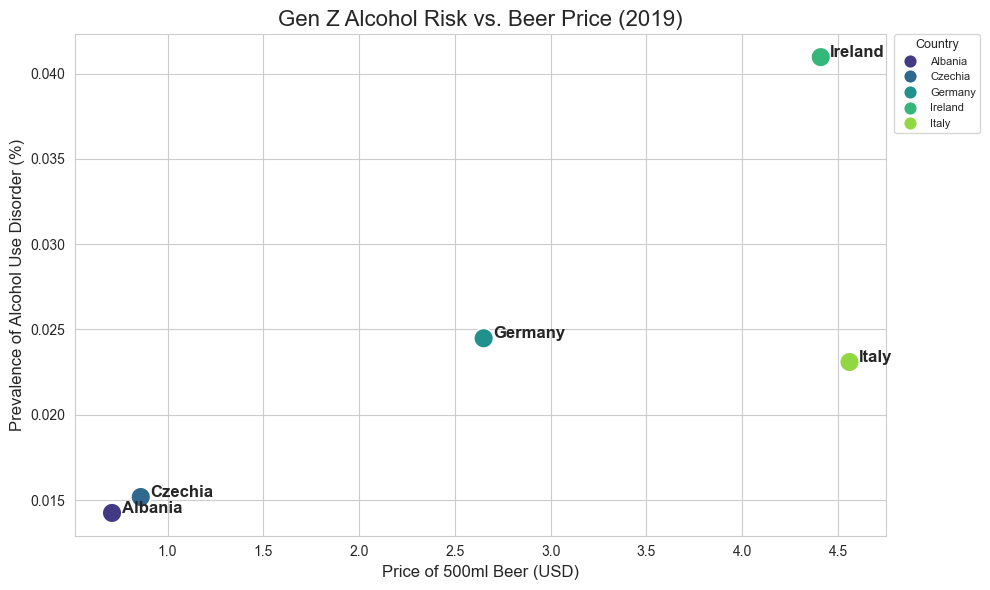

In [212]:

# 1. Filter for our "Gen Z" target (15-19 years, Both Sexes, Year 2019)
gen_z_2019 = final_study_df[
    (final_study_df['year'] == 2019) & 
    (final_study_df['generation']== 'Gen_Z') & 
    (final_study_df['sex'] == 'Both Sexes')
].groupby(['location','generation','beer_price_usd'])['percent_of_prevalence'].mean().reset_index()

# 2. Create the Scatter Plot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Plotting Price vs Prevalence
plot = sns.scatterplot(
    data=gen_z_2019, 
    x='beer_price_usd', 
    y='percent_of_prevalence', 
    hue='location', 
    s=200, 
    palette='viridis'
)

# Adding labels for each dot
for i in range(gen_z_2019.shape[0]):
    plt.text(
        gen_z_2019.beer_price_usd.iloc[i]+0.05, 
        gen_z_2019.percent_of_prevalence.iloc[i], 
        gen_z_2019.location.iloc[i], 
        fontsize=12, fontweight='bold'
    )

plt.title('Gen Z Alcohol Risk vs. Beer Price (2019)', fontsize=16)
plt.xlabel('Price of 500ml Beer (USD)', fontsize=12)
plt.ylabel('Prevalence of Alcohol Use Disorder (%)', fontsize=12)
plt.legend(
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    borderaxespad=0,
    fontsize=8,
    markerscale=0.7,
    title='Country',
    title_fontsize=9
)

plt.tight_layout()

plt.savefig('price_vs_prevalence_genz.png')

In [216]:
gen_z_2019.to_csv('prevalence_vs_beer_clean.csv', index=False)

In [215]:
gen_z_2019

,location,generation,beer_price_usd,percent_of_prevalence
0,Albania,Gen_Z,0.71,0.014243
1,Czechia,Gen_Z,0.86,0.015176
2,Germany,Gen_Z,2.65,0.024485
3,Ireland,Gen_Z,4.41,0.040968
4,Italy,Gen_Z,4.56,0.023092


In [101]:
final_study_df

,location,sex,age,year,precent_of_prevalence,upper_bound,lower_bound,generation,beer_price_usd,tax_revenue_pct,household_exp_pct,liters_per_capita
0,Albania,Male,15-19 years,2010,0.009399,0.015126,0.005307,Millennial,0.71,NaN,1.3,4.216621
1,Albania,Female,15-19 years,2010,0.006388,0.010502,0.003393,Millennial,0.71,NaN,1.3,4.216621
2,Albania,Both Sexes,15-19 years,2010,0.007886,0.012866,0.004241,Millennial,0.71,NaN,1.3,4.216621
3,Albania,Male,20-24 years,2010,0.025625,0.040491,0.015240,Millennial,0.71,NaN,1.3,4.216621
4,Albania,Female,20-24 years,2010,0.018424,0.029211,0.010647,Millennial,0.71,NaN,1.3,4.216621
...,...,...,...,...,...,...,...,...,...,...,...,...
895,Italy,Female,35-39 years,2019,0.015842,0.021173,0.011176,Millennial,4.56,0.6,1.6,7.816667
896,Italy,Both Sexes,35-39 years,2019,0.025459,0.032900,0.018591,Millennial,4.56,0.6,1.6,7.816667
897,Italy,Male,40-44 years,2019,0.029761,0.040194,0.021383,Gen_X,4.56,0.6,1.6,7.816667
898,Italy,Female,40-44 years,2019,0.012890,0.018061,0.008861,Gen_X,4.56,0.6,1.6,7.816667


In [217]:
cons_profile = pd.read_csv('/Users/nestocr/Documents/DataAnalytics_BootCamp/da-capstone-project-dayane-ernesto/Cleaned Sets/Consumption_in_Europe_2000-2020.csv')
cons_profile.head()

,Title,Year,Liters Pure Alcohol Consumed,NumericValue,Min,Max
0,Azerbaijan,2008,0.6 [0.3 - 1.0],0.568046,0.251125,0.964423
1,Portugal,2012,10.0 [8.4 - 11.7],10.040000,8.401023,11.692693
2,Tajikistan,2020,0.8 [0.3 - 1.2],0.760516,0.340246,1.209908
3,Netherlands (Kingdom of the),2008,9.4 [7.7 - 11.0],9.350000,7.660837,10.963466
4,Portugal,2018,10.6 [9.0 - 12.2],10.553597,8.961007,12.158488


In [218]:
cons_profile.drop(columns=['Liters Pure Alcohol Consumed'],inplace=True)


In [219]:
cons_profile.rename(columns={'NumericValue':'liters_alcohol_consumption'})


,Title,Year,liters_alcohol_consumption,Min,Max
0,Azerbaijan,2008,0.568046,0.251125,0.964423
1,Portugal,2012,10.040000,8.401023,11.692693
2,Tajikistan,2020,0.760516,0.340246,1.209908
3,Netherlands (Kingdom of the),2008,9.350000,7.660837,10.963466
4,Portugal,2018,10.553597,8.961007,12.158488
...,...,...,...,...,...
1168,Serbia,2020,7.856437,6.258593,9.237920
1169,Georgia,2005,5.366606,4.120049,6.467267
1170,Switzerland,2020,8.630000,7.243281,10.135972
1171,Czechia,2021,12.992705,11.155746,14.701137


In [220]:
cons_profile = cons_profile[
    (cons_profile['Title'].isin(['Ireland', 'Italy','Germany','Albania','Czechia'])) &
    (cons_profile['Year'].isin([2010,2011,2012,2013,2014,2015,2016,2017,2018,2019]))]

In [221]:
cons_profile.rename(columns={'Title':'location','Year':'year','NumericValue':'liters_per_capita'}, inplace=True)


In [222]:
cons_profile.head(1)

,location,year,liters_per_capita,Min,Max
27,Albania,2016,4.305092,3.284676,5.404786


In [223]:
cons_profile=cons_profile.sort_values('year').groupby('location').tail(1)
cons_profile=cons_profile[['location','liters_per_capita']]


In [224]:
final_study_df=pd.merge(final_study_df,cons_profile, on='location',how='left')


In [226]:
print("--- Check: Does every Gen Z row now have a 'National Context' Liter count? ---")
print(final_study_df[['location', 'year', 'percent_of_prevalence', 'liters_per_capita']].head())

--- Check: Does every Gen Z row now have a 'National Context' Liter count? ---
  location  year  percent_of_prevalence  liters_per_capita
0  Albania  2010               0.009399           4.216621
1  Albania  2010               0.006388           4.216621
2  Albania  2010               0.007886           4.216621
3  Albania  2010               0.025625           4.216621
4  Albania  2010               0.018424           4.216621


In [228]:
genz_env = final_study_df[(final_study_df['year'] == 2019) & 
                          (final_study_df['age'].isin(['15-19 years','20-24 years'])) & 
                          (final_study_df['sex'] == 'Both Sexes')]

In [234]:
final_study_df

,location,sex,age,year,percent_of_prevalence,upper_bound,lower_bound,generation,prevalence %,beer_price_usd,tax_revenue_pct,household_exp_pct,liters_per_capita
0,Albania,Male,15-19 years,2010,0.009399,0.015126,0.005307,Millennial,0.94%,0.71,NaN,1.3,4.216621
1,Albania,Female,15-19 years,2010,0.006388,0.010502,0.003393,Millennial,0.64%,0.71,NaN,1.3,4.216621
2,Albania,Both Sexes,15-19 years,2010,0.007886,0.012866,0.004241,Millennial,0.79%,0.71,NaN,1.3,4.216621
3,Albania,Male,20-24 years,2010,0.025625,0.040491,0.015240,Millennial,2.56%,0.71,NaN,1.3,4.216621
4,Albania,Female,20-24 years,2010,0.018424,0.029211,0.010647,Millennial,1.84%,0.71,NaN,1.3,4.216621
...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,Italy,Female,35-39 years,2019,0.015842,0.021173,0.011176,Millennial,1.58%,4.56,0.6,1.6,7.816667
896,Italy,Both Sexes,35-39 years,2019,0.025459,0.032900,0.018591,Millennial,2.55%,4.56,0.6,1.6,7.816667
897,Italy,Male,40-44 years,2019,0.029761,0.040194,0.021383,Gen_X,2.98%,4.56,0.6,1.6,7.816667
898,Italy,Female,40-44 years,2019,0.012890,0.018061,0.008861,Gen_X,1.29%,4.56,0.6,1.6,7.816667


In [236]:
gen_z_env_grouped = final_study_df[
    (final_study_df['year'] == 2019) & 
    (final_study_df['generation']=='Gen_Z') &
    (final_study_df['sex'] == 'Both Sexes')
].groupby(['location', 'generation', 'liters_per_capita'])['percent_of_prevalence'].mean().reset_index()

In [237]:
gen_z_env_grouped.head()

,location,generation,liters_per_capita,percent_of_prevalence
0,Albania,Gen_Z,4.216621,0.014243
1,Czechia,Gen_Z,13.050000,0.015176
2,Germany,Gen_Z,10.820000,0.024485
3,Ireland,Gen_Z,10.613333,0.040968
4,Italy,Gen_Z,7.816667,0.023092


In [238]:
gen_z_env_grouped.to_csv('consumption_vs_prevalence.csv', index=False)

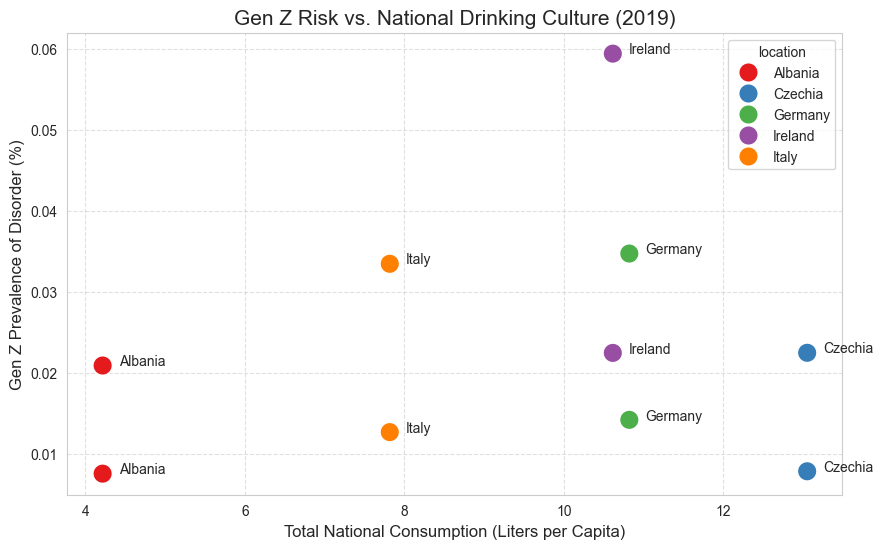

In [231]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=genz_env, x='liters_per_capita', y='percent_of_prevalence', 
                hue='location', s=200, palette='Set1')

# Add labels
for i in range(genz_env.shape[0]):
    plt.text(genz_env.liters_per_capita.iloc[i]+0.2, 
             genz_env.percent_of_prevalence.iloc[i], 
             genz_env.location.iloc[i])

plt.title('Gen Z Risk vs. National Drinking Culture (2019)', fontsize=15)
plt.xlabel('Total National Consumption (Liters per Capita)', fontsize=12)
plt.ylabel('Gen Z Prevalence of Disorder (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

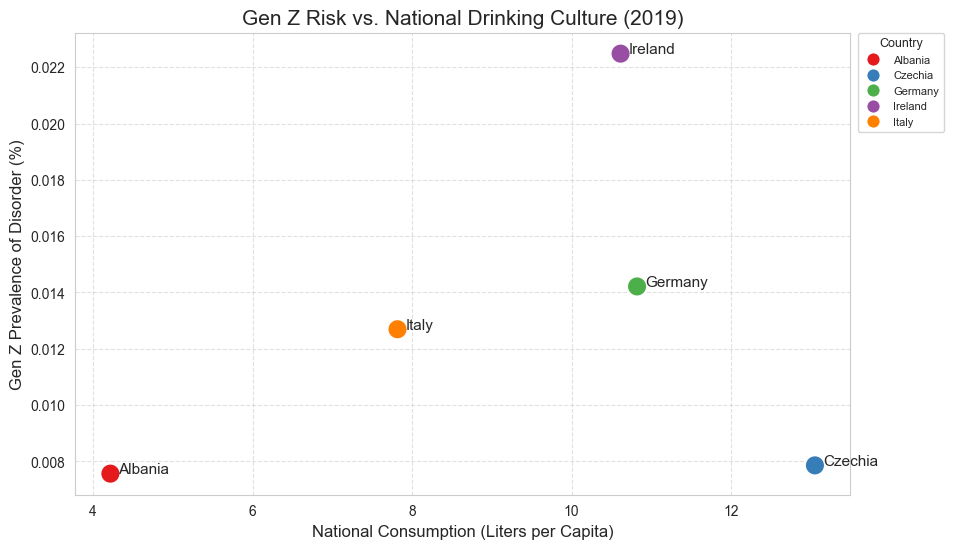

In [99]:
# 1. Filter for the 2019 Gen Z snapshot
# Ensure 'liters_per_capita' is in this dataframe from our previous merge
genz_cultural = final_study_df[
    (final_study_df['year'] == 2019) & 
    (final_study_df['age'] == '15-19 years') & 
    (final_study_df['sex'] == 'Both Sexes')
]

plt.figure(figsize=(10, 6))

# 2. CORRECTED: Set x to 'liters_per_capita'
plot = sns.scatterplot(
    data=genz_cultural, 
    x='liters_per_capita', 
    y='precent_of_prevalence', 
    hue='location', 
    s=200, 
    palette='Set1'
)

# 3. Updated Labels to match the new data
for i in range(genz_cultural.shape[0]):
    plt.text(
        genz_cultural.liters_per_capita.iloc[i] + 0.1, 
        genz_cultural.precent_of_prevalence.iloc[i], 
        genz_cultural.location.iloc[i], 
        fontsize=11
    )

plt.title('Gen Z Risk vs. National Drinking Culture (2019)', fontsize=15)
plt.xlabel('National Consumption (Liters per Capita)', fontsize=12) # NEW LABEL
plt.ylabel('Gen Z Prevalence of Disorder (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    borderaxespad=0,
    fontsize=8,
    markerscale=0.7,
    title='Country',
    title_fontsize=9
)
plt.tight_layout
plt.savefig('master_economic_bubble_chart.png')
plt.show()

In [258]:
# 1. Filter for our specific Gender comparison (removing 'Both Sexes')
gender_df = final_study_df[
    (final_study_df['age'] == '15-19 years') & 
    (final_study_df['sex'] != 'Both Sexes')
]

In [259]:
gender_df.head()

,location,sex,age,year,percent_of_prevalence,upper_bound,lower_bound,generation,prevalence %,beer_price_usd,tax_revenue_pct,household_exp_pct,liters_per_capita
0,Albania,Male,15-19 years,2010,0.009399,0.015126,0.005307,Millennial,0.94%,0.71,NaN,1.3,4.216621
1,Albania,Female,15-19 years,2010,0.006388,0.010502,0.003393,Millennial,0.64%,0.71,NaN,1.3,4.216621
18,Albania,Male,15-19 years,2011,0.009435,0.014972,0.005258,Millennial,0.94%,0.71,NaN,1.3,4.216621
19,Albania,Female,15-19 years,2011,0.006384,0.010457,0.003392,Millennial,0.64%,0.71,NaN,1.3,4.216621
36,Albania,Male,15-19 years,2012,0.009483,0.014934,0.005099,Gen_Z,0.95%,0.71,NaN,1.3,4.216621


In [260]:
gender_df.to_csv('consumption_males_vs_females.csv',index=False)

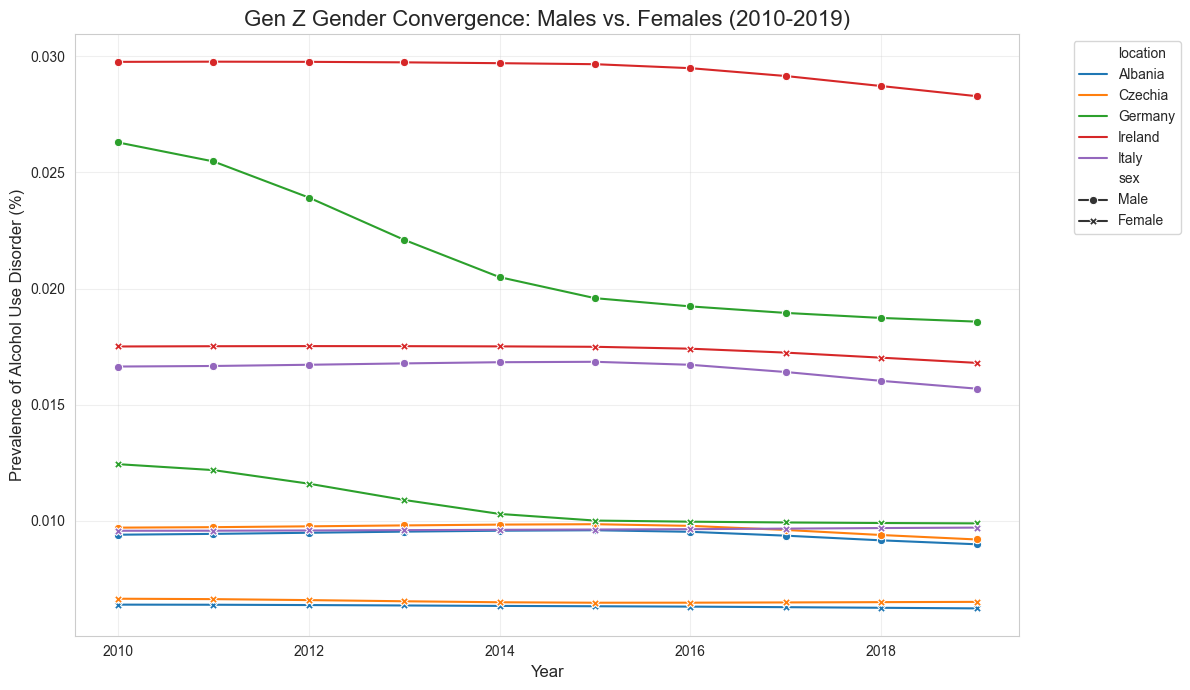

In [74]:
# 2. Create the Plot
plt.figure(figsize=(12, 7))
sns.lineplot(
    data=gender_df, 
    x='year', 
    y='precent_of_prevalence', 
    hue='location', 
    style='sex', 
    markers=True, 
    dashes=False
)

plt.title('Gen Z Gender Convergence: Males vs. Females (2010-2019)', fontsize=16)
plt.ylabel('Prevalence of Alcohol Use Disorder (%)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('GenZ_gender_convergance:Male_vs_Female.png')
plt.show()

In [55]:
genz_stats = final_study_df[(final_study_df['year'] == 2019) & 
                          (final_study_df['age'] == '15-19 years') & 
                          (final_study_df['sex'] == 'Both Sexes')].dropna(subset=['liters_per_capita','precent_of_prevalence'])
r_value = genz_stats['liters_per_capita'].corr(genz_stats['precent_of_prevalence'])
print(f"---The 'Cultural Grip' Statistic---")
print(f"pearsonCorrelation (r): {r_value:.3f}")
if r_value > 0.7:
    print("Result: STRONG LINK. Gen Z is a mirror of national culture")
elif 0.4 <= r_value <= 0.7:
    print("Result: MODERATE LINK. Culture matters, but Gen Z is starting to deviate")
else:
    print("Result: WEAK / NO LINK. Gen Z has successfully decoupled from national cultural drinking habits")

---The 'Cultural Grip' Statistic---
pearsonCorrelation (r): 0.280
Result: WEAK / NO LINK. Gen Z has successfully decoupled from national cultural drinking habits


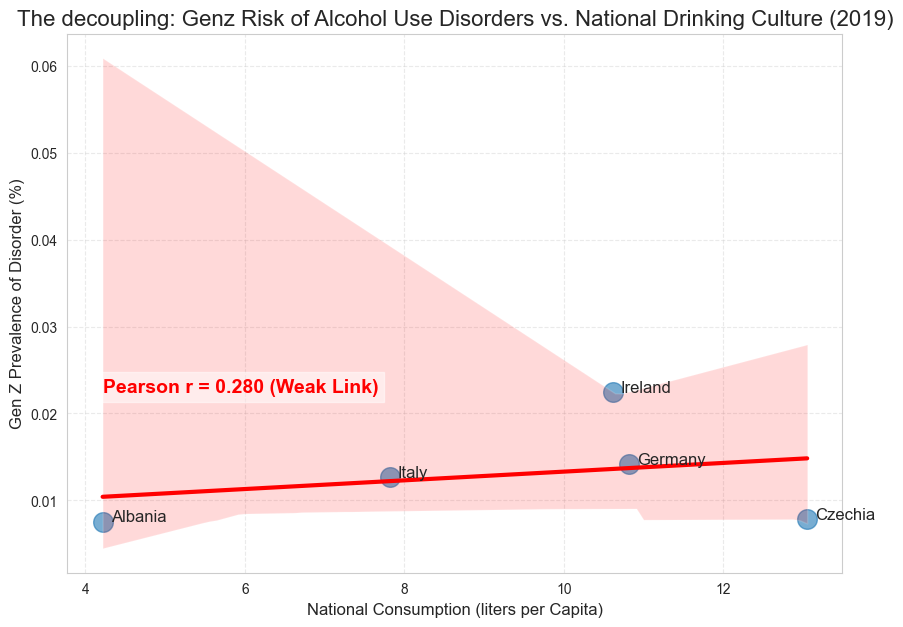

In [75]:
plt.figure(figsize=(10,7))
sns.regplot(
    data=genz_stats,
    x='liters_per_capita',
    y='precent_of_prevalence',
    scatter_kws={'s':200, 'alpha': 0.6},
    line_kws={'color':'red','linewidth': 3}
)
plt.text(
    x=genz_stats['liters_per_capita'].min(),
    y=genz_stats['precent_of_prevalence'].max(),
    s=f'Pearson r = 0.280 (Weak Link)',
    fontsize=14, fontweight='bold', color='red',
    bbox=dict(facecolor='white', alpha=0.5)
)
for i in range(genz_stats.shape[0]):
    if genz_stats.location.iloc[i] in ['Czechia', 'Ireland', 'Italy', 'Germany','Albania']:
        plt.text(
            genz_stats.liters_per_capita.iloc[i] + 0.1,
            genz_stats.precent_of_prevalence.iloc[i],
            genz_stats.location.iloc[i],
            fontsize=12
        )
plt.title('The decoupling: Genz Risk of Alcohol Use Disorders vs. National Drinking Culture (2019)', fontsize=16)
plt.xlabel('National Consumption (liters per Capita)', fontsize=12)
plt.ylabel('Gen Z Prevalence of Disorder (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.savefig('Pearsons_Correlation.png')

In [65]:
from scipy import stats as st

In [71]:
data_2010 = final_study_df[(final_study_df['year']==2010) &
                            (final_study_df['age'] == '20-24 years') &
                            (final_study_df['sex']=='Both Sexes')].sort_values('location')
data_2019 = final_study_df[(final_study_df['year']==2019) &
                            (final_study_df['age'] == '20-24 years') &
                            (final_study_df['sex']=='Both Sexes')].sort_values('location')
common_locations = set(data_2010['location']).intersection(set(data_2019['location']))
val_2010 = data_2010[data_2010['location'].isin(common_locations)]['precent_of_prevalence']
val_2019 = data_2019[data_2019['location'].isin(common_locations)]['precent_of_prevalence']

t_stat, p_value =st.ttest_rel(val_2010, val_2019)
print(f"---The Significance Test---")
print(f"T-Statistic:{t_stat:.4f}")
print(f"P-Value:{p_value:.10f}")

if p_value < 0.05:
    print("Result: Statistically Significant. The drop is a real generational shift")
else:
    print("Result: Not Significant: The change could be random fluctuation")




                            

---The Significance Test---
T-Statistic:1.6366
P-Value:0.1770503957
Result: Not Significant: The change could be random fluctuation


In [79]:
genz_stats.head(10)

,location,sex,age,year,precent_of_prevalence,upper_bound,lower_bound,generation,beer_price_usd,tax_revenue_pct,household_exp_pct,liters_per_capita
164,Albania,Both Sexes,15-19 years,2019,0.007564,0.012128,0.004003,Gen_Z,0.71,NaN,1.3,4.216621
344,Czechia,Both Sexes,15-19 years,2019,0.007858,0.012344,0.004390,Gen_Z,0.86,NaN,1.5,13.050000
524,Germany,Both Sexes,15-19 years,2019,0.014213,0.021719,0.008129,Gen_Z,2.65,0.6,NaN,10.820000
704,Ireland,Both Sexes,15-19 years,2019,0.022482,0.035066,0.013024,Gen_Z,4.41,0.6,2.5,10.613333
884,Italy,Both Sexes,15-19 years,2019,0.012693,0.017611,0.008768,Gen_Z,4.56,0.6,1.6,7.816667


In [82]:
genz_stats['resiliance_score'] = genz_stats['liters_per_capita'] / (genz_stats['precent_of_prevalence']*100)


In [98]:
genz_stats.sort_values('resiliance_score')

,location,sex,age,year,precent_of_prevalence,upper_bound,lower_bound,generation,beer_price_usd,tax_revenue_pct,household_exp_pct,liters_per_capita,resiliance_score
704,Ireland,Both Sexes,15-19 years,2019,0.022482,0.035066,0.013024,Gen_Z,4.41,0.6,2.5,10.613333,4.720848
164,Albania,Both Sexes,15-19 years,2019,0.007564,0.012128,0.004003,Gen_Z,0.71,NaN,1.3,4.216621,5.574612
884,Italy,Both Sexes,15-19 years,2019,0.012693,0.017611,0.008768,Gen_Z,4.56,0.6,1.6,7.816667,6.158181
524,Germany,Both Sexes,15-19 years,2019,0.014213,0.021719,0.008129,Gen_Z,2.65,0.6,NaN,10.820000,7.612611
344,Czechia,Both Sexes,15-19 years,2019,0.007858,0.012344,0.004390,Gen_Z,0.86,NaN,1.5,13.050000,16.607738


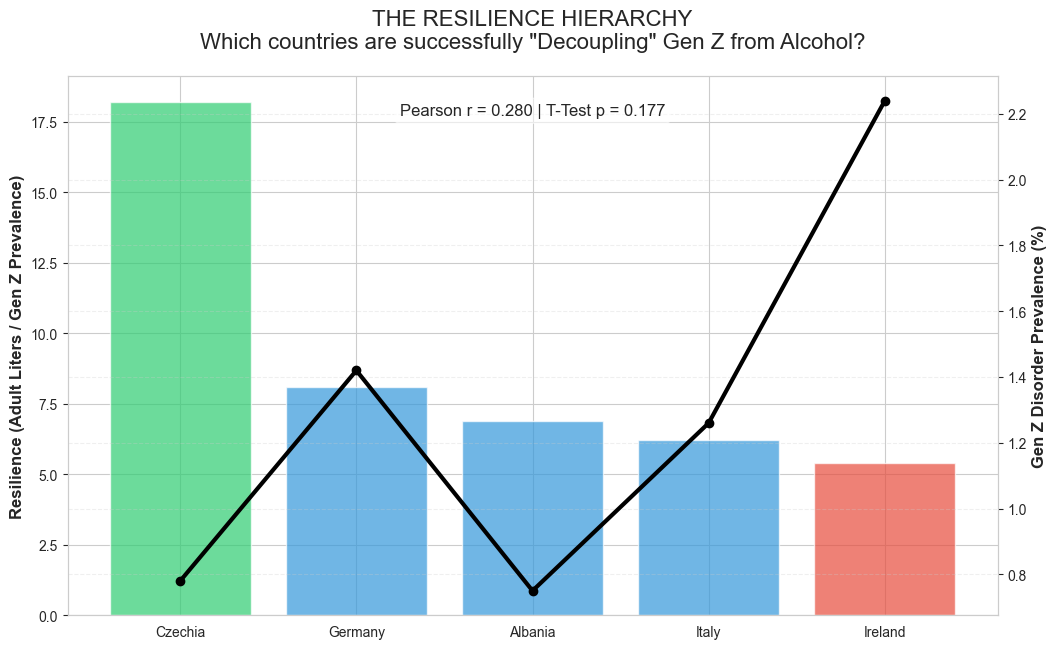

In [89]:
# 1. Create the summary data for the final visual
# (Using the values we calculated in the Resilience Table)
summary_data = {
    'Location': ['Czechia', 'Germany', 'Albania', 'Italy', 'Ireland'],
    'Gen Z Risk (%)': [0.78, 1.42, 0.75, 1.26, 2.24],
    'Resilience': [18.2, 8.1, 6.9, 6.2, 5.4],
    'Male_Drop': [-15, -29.3, -5, -5.7, -4.9] # Estimated/Calculated drops
}
final_plot_df = pd.DataFrame(summary_data).sort_values('Resilience', ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 7))

# 2. Bar Chart for Resilience (The 'Strength' of the Generation)
colors = ['#2ecc71' if x > 10 else '#3498db' if x > 6 else '#e74c3c' for x in final_plot_df['Resilience']]
bars = ax1.bar(final_plot_df['Location'], final_plot_df['Resilience'], color=colors, alpha=0.7, label='Resilience Score')

# 3. Line Chart for Risk (The Actual Outcome)
ax2 = ax1.twinx()
ax2.plot(final_plot_df['Location'], final_plot_df['Gen Z Risk (%)'], color='black', marker='o', linewidth=3, label='Gen Z Risk %')

# 4. Styling
ax1.set_ylabel('Resilience (Adult Liters / Gen Z Prevalence)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Gen Z Disorder Prevalence (%)', fontsize=12, fontweight='bold')
plt.title('THE RESILIENCE HIERARCHY\nWhich countries are successfully "Decoupling" Gen Z from Alcohol?', fontsize=16, pad=20)

# Adding the 'p-value' and 'r-value' as a watermark/note
plt.text(0.5, 0.95, f'Pearson r = 0.280 | T-Test p = 0.177', transform=ax1.transAxes, 
         ha='center', fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

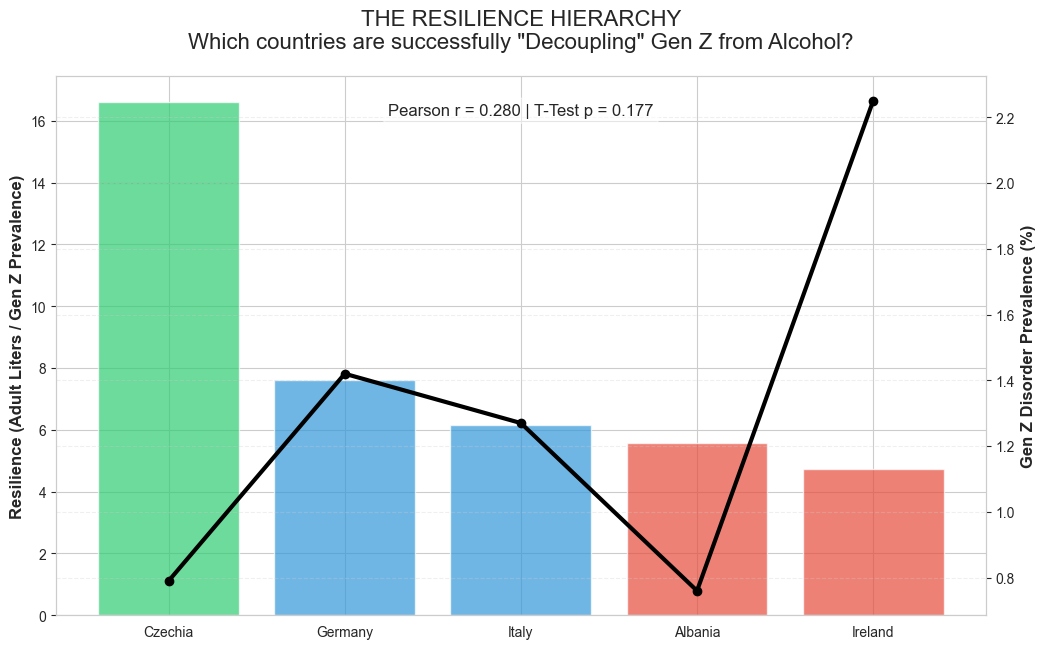

<Figure size 640x480 with 0 Axes>

In [95]:
# 1. Create the summary data for the final visual
# (Using the values we calculated in the Resilience Table)
summary_data = {'Location':genz_stats['location'],
'GenZ Risk (%)':(genz_stats['precent_of_prevalence']*100).round(2),
'Resilience':genz_stats['resiliance_score'].round(2),
'Male_Drop': [-15, -29.3, -5, -5.7, -4.9]}

final_plot_df = pd.DataFrame(summary_data).sort_values('Resilience', ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 7))

# 2. Bar Chart for Resilience (The 'Strength' of the Generation)
colors = ['#2ecc71' if x > 10 else '#3498db' if x > 6 else '#e74c3c' for x in final_plot_df['Resilience']]
bars = ax1.bar(final_plot_df['Location'], final_plot_df['Resilience'], color=colors, alpha=0.7, label='Resilience Score')

# 3. Line Chart for Risk (The Actual Outcome)
ax2 = ax1.twinx()
ax2.plot(final_plot_df['Location'], final_plot_df['GenZ Risk (%)'], color='black', marker='o', linewidth=3, label='Gen Z Risk %')

# 4. Styling
ax1.set_ylabel('Resilience (Adult Liters / Gen Z Prevalence)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Gen Z Disorder Prevalence (%)', fontsize=12, fontweight='bold')
plt.title('THE RESILIENCE HIERARCHY\nWhich countries are successfully "Decoupling" Gen Z from Alcohol?', fontsize=16, pad=20)

# Adding the 'p-value' and 'r-value' as a watermark/note
plt.text(0.5, 0.95, f'Pearson r = 0.280 | T-Test p = 0.177', transform=ax1.transAxes, 
         ha='center', fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()
plt.savefig('resiliance_hierarchy.png')

In [96]:
master_prevalence = pd.read_csv('/Users/nestocr/Documents/DataAnalytics_BootCamp/da-capstone-project-dayane-ernesto/Cleaned Sets/master_prevalence_2005_2023.csv')

In [105]:
# Check what age group the resilience calculation was based on
# and what the actual 2019 prevalence looks like per age group
# for our five champion countries

champion_countries = ['Germany', 'Ireland', 'Italy', 'Albania', 'Czechia']

prevalence_check = master_prevalence[
    (master_prevalence['location'].isin(champion_countries)) &
    (master_prevalence['year'] == 2019) &
    (master_prevalence['sex'] == 'Both Sexes')
][['location', 'age', 'precent_of_prevalence']].sort_values(
    ['location', 'age']
)

print(prevalence_check.to_string())

     location          age  precent_of_prevalence
254   Albania  15-19 years               0.007564
257   Albania  20-24 years               0.020923
260   Albania  25-29 years               0.026512
263   Albania  30-34 years               0.027203
266   Albania  35-39 years               0.023782
269   Albania  40-44 years               0.020352
3332  Czechia  15-19 years               0.007858
3335  Czechia  20-24 years               0.022495
3338  Czechia  25-29 years               0.031524
3341  Czechia  30-34 years               0.035251
3344  Czechia  35-39 years               0.034256
3347  Czechia  40-44 years               0.032554
5042  Germany  15-19 years               0.014213
5045  Germany  20-24 years               0.034756
5048  Germany  25-29 years               0.036442
5051  Germany  30-34 years               0.034149
5054  Germany  35-39 years               0.032862
5057  Germany  40-44 years               0.031829
6410  Ireland  15-19 years               0.022482


In [106]:
# Step 1: Calculate mean prevalence across ALL age groups for 2019
# This gives one number per country representing overall AUD burden
mean_prevalence_2019 = master_prevalence[
    (master_prevalence['location'].isin(champion_countries)) &
    (master_prevalence['year'] == 2019) &
    (master_prevalence['sex'] == 'Both Sexes')
].groupby('location')['precent_of_prevalence'].mean().reset_index()

mean_prevalence_2019.columns = ['location', 'mean_prevalence']
mean_prevalence_2019['mean_prevalence_pct'] = (
    mean_prevalence_2019['mean_prevalence'] * 100
).round(3)

print("--- Mean Prevalence Across All Age Groups (2019) ---")
print(mean_prevalence_2019.sort_values('mean_prevalence_pct'))

--- Mean Prevalence Across All Age Groups (2019) ---
  location  mean_prevalence  mean_prevalence_pct
0  Albania         0.021056                2.106
4    Italy         0.026250                2.625
1  Czechia         0.027323                2.732
2  Germany         0.030709                3.071
3  Ireland         0.050606                5.061


In [ ]:
consumption_final

In [107]:
print(consumption_final.columns.tolist())
print(consumption_final.head())


NameError: name 'consumption_final' is not defined

In [ ]:
from sklearn.cluster import AgglomerativeClustering


In [3]:
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
cluster_df=pd.read_csv('/Users/nestocr/Documents/DataAnalytics_BootCamp/da-capstone-project-dayane-ernesto/Cleaned Sets/clustering_ready_2019.csv')

In [8]:
scaler = StandardScaler()

In [9]:
X_scaled=scaler.fit_transform(cluster_df[['prevalence', 'liters/capita', 'abstention_rate']])

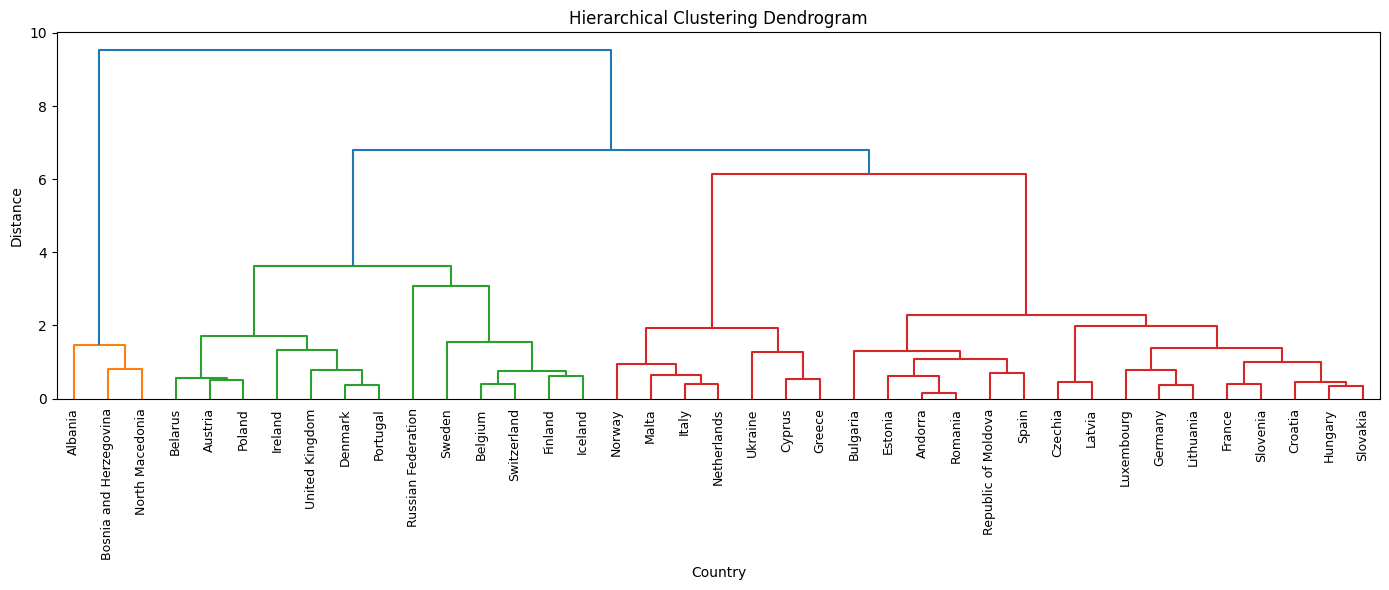

In [10]:
plt.figure(figsize=(14, 6))
linkage_matrix = linkage(X_scaled, method='ward')
dendrogram(linkage_matrix, labels=cluster_df['location'].values, leaf_rotation=90, leaf_font_size=9)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Country')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [11]:
agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
cluster_df['cluster'] = agg.fit_predict(X_scaled)

In [12]:
cluster_df.head()

,location,prevalence,liters/capita,abstention_rate,cluster
0,Albania,0.020138,4.216621,33.654735,3
1,Andorra,0.026643,10.526667,10.239672,2
2,Austria,0.038762,11.453333,10.144593,0
3,Belarus,0.037897,10.250000,12.136096,0
4,Belgium,0.035462,8.930000,12.199580,0


In [13]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

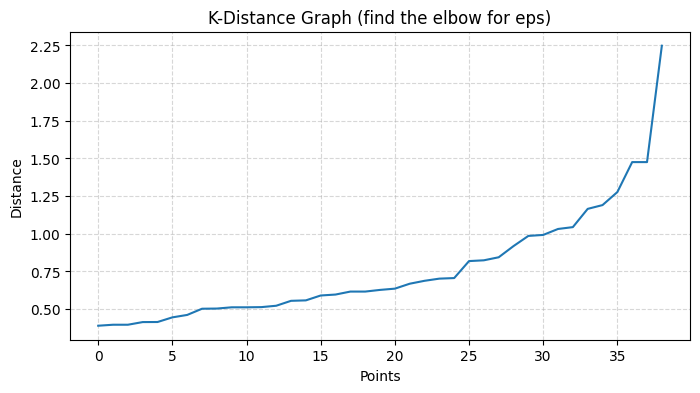

                  location  cluster
0                  Albania       -1
25         North Macedonia       -1
31      Russian Federation       -1
5   Bosnia and Herzegovina       -1
37                 Ukraine       -1
34                   Spain        0
32                Slovakia        0
35                  Sweden        0
30                 Romania        0
20                  Latvia        0
28                Portugal        0
27                  Poland        0
26                  Norway        0
36             Switzerland        0
24             Netherlands        0
23                   Malta        0
22              Luxembourg        0
21               Lithuania        0
33                Slovenia        0
29     Republic of Moldova        0
19                   Italy        0
17                 Iceland        0
1                  Andorra        0
2                  Austria        0
3                  Belarus        0
4                  Belgium        0
6                 Bulgaria  

In [ ]:
neighbors = NearestNeighbors(n_neighbors=3)
neighbors.fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
distances = sorted(distances[:, 2])

plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.title('K-Distance Graph (find the elbow for eps)')
plt.xlabel('Points')
plt.ylabel('Distance')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

dbscan = DBSCAN(eps=1.0, min_samples=3)
cluster_df['cluster'] = dbscan.fit_predict(X_scaled)

# Check results — -1 means outlier
print(cluster_df[['location', 'cluster']].sort_values('cluster'))
print('\nCluster counts:')
print(cluster_df['cluster'].value_counts())

In [17]:
abstention = pd.read_csv('/Users/nestocr/Documents/DataAnalytics_BootCamp/da-capstone-project-dayane-ernesto/Cleaned Sets/Abstention_in_Europe_2000-2020.csv')

In [20]:
import seaborn as sns

In [245]:
abstention['Year'].unique()

array([2012, 2004, 2014, 2018, 2003, 2016, 2000, 2015, 2002, 2001, 2020,
       2019, 2017, 2007, 2009, 2010, 2008, 2005, 2006, 2013, 2011])

In [246]:
df_avg=abstention.groupby('Title', as_index=False)['NumericValue'].mean()

In [247]:
df_avg.to_csv('abstention_histogram.csv', index=False)

In [83]:
df_avg.head(1)

,Title,NumericValue
0,Albania,49.804959


In [28]:
import plotly.express as px

In [41]:
import matplotlib.ticker as mticker

/var/folders/f7/v5tc68r1421067916_433tqh0000gn/T/ipykernel_7675/2637825103.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


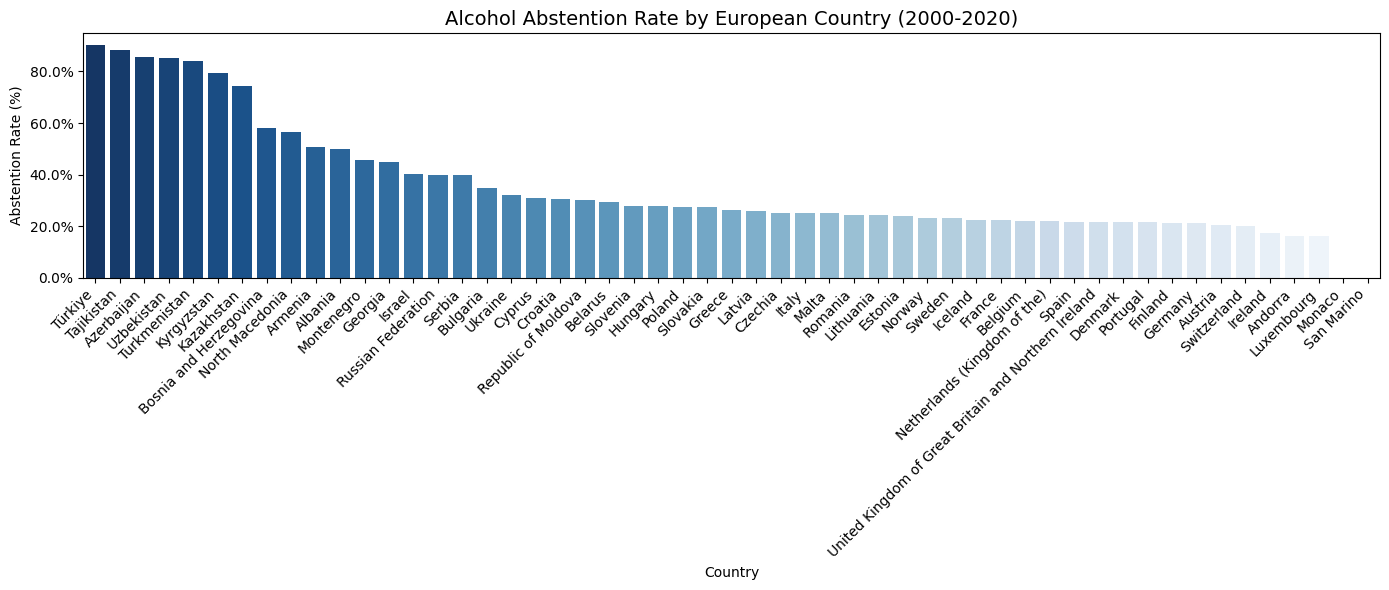

In [42]:
plt.figure(figsize=(14, 6))
sns.barplot(
    data=df_avg.sort_values('NumericValue', ascending=False),
    x='Title',
    y='NumericValue',
    palette='Blues_r'
)
plt.title('Alcohol Abstention Rate by European Country (2000-2020)', fontsize=14)
plt.xlabel('Country')
plt.ylabel('Abstention Rate (%)')
plt.xticks(rotation=45, ha='right')                 # angle labels for readability
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
plt.tight_layout()
plt.show()

In [85]:
fig = px.histogram(
    df_avg,
    x='NumericValue',
    nbins=10,
    title='Abstinence as % of Population in European Nations (2000 - 2020)',
    labels={'NumericValue': '% of Population that abstains from alcohol consumption'},
    hover_data=['Title']
)
fig.update_layout(
    plot_bgcolor='white',
    xaxis=dict(showgrid=False, title='% of Abstainers'),
    yaxis=dict(showgrid=True, gridcolor='lightgrey', title='Number of Countries'),
    bargap=0.05,
    showlegend=False
)

In [248]:
consumption = pd.read_csv('/Users/nestocr/Documents/DataAnalytics_BootCamp/da-capstone-project-dayane-ernesto/Cleaned Sets/Consumption_in_Europe_2000-2020.csv')

In [249]:
con_avg=consumption.groupby('Title', as_index=False)['NumericValue'].mean()

In [49]:
consumption.head(1)

,Title,Year,Liters Pure Alcohol Consumed,NumericValue,Min,Max
0,Azerbaijan,2008,0.6 [0.3 - 1.0],0.568046,0.251125,0.964423


In [250]:
con_avg.head(1)


,Title,NumericValue
0,Albania,4.442451


In [251]:
con_avg.to_csv('consumption_histogram.csv')

In [82]:
fig = px.histogram(
    con_avg,
    x='NumericValue',
    nbins=10,
    title='Consumption of Alcohol in Liters/Capita in European Nations (2000 - 2020)',
    labels={'NumericValue': 'Liters of Pure Alcohol Consumed'},
    hover_data=['Title']
)
fig.update_layout(
    plot_bgcolor='white',
    xaxis=dict(showgrid=False, title='% of Population with Alcohol Use Disorders'),
    yaxis=dict(showgrid=True, gridcolor='lightgrey', title='Number of Countries'),
    bargap=0.05,
    showlegend=False
)


/var/folders/f7/v5tc68r1421067916_433tqh0000gn/T/ipykernel_7675/163222222.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


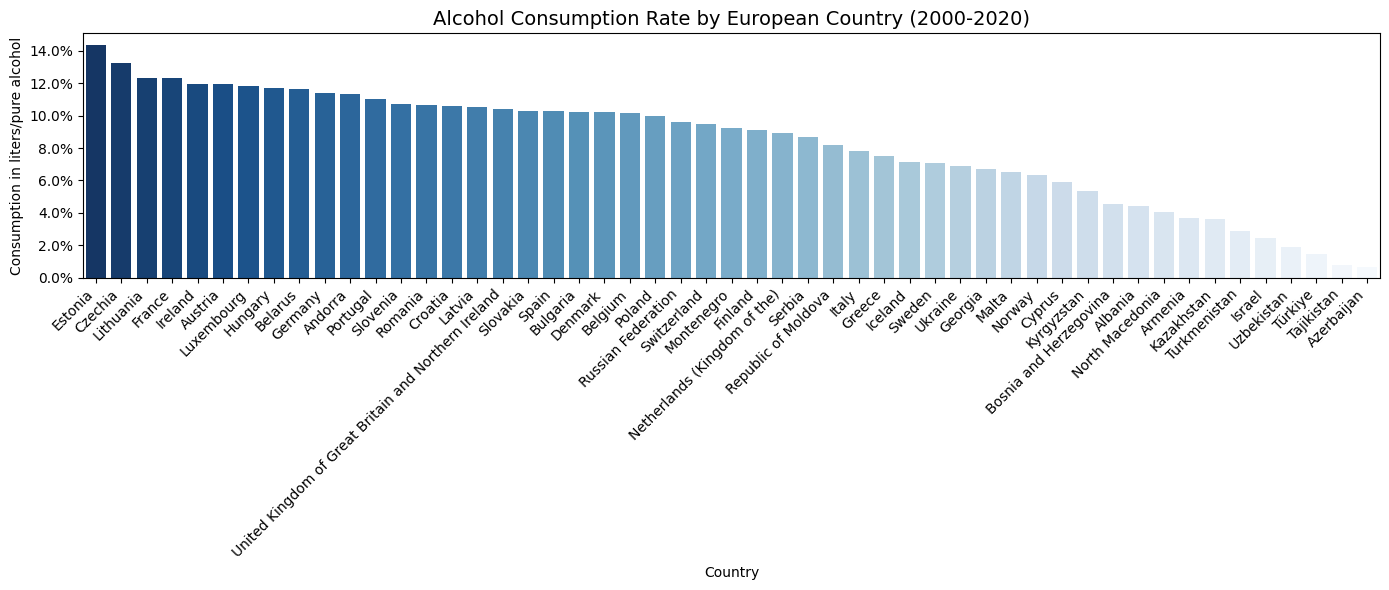

In [50]:
plt.figure(figsize=(14, 6))
sns.barplot(
    data=con_avg.sort_values('NumericValue', ascending=False),
    x='Title',
    y='NumericValue',
    palette='Blues_r'
)
plt.title('Alcohol Consumption Rate by European Country (2000-2020)', fontsize=14)
plt.xlabel('Country')
plt.ylabel('Consumption in liters/pure alcohol')
plt.xticks(rotation=45, ha='right')                 # angle labels for readability
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
plt.tight_layout()
plt.show()

In [252]:
prev=pd.read_csv('/Users/nestocr/Documents/DataAnalytics_BootCamp/da-capstone-project-dayane-ernesto/Cleaned Sets/master_prevalence_2005_2023.csv')

In [253]:
prev1 = prev[prev['sex']== 'Both Sexes']

In [254]:
prev1.head(1)

,location,sex,age,year,precent_of_prevalence,upper_bound,lower_bound
2,Albania,Both Sexes,15-19 years,2005,0.007746,0.012591,0.004332


In [255]:
prev_avg = prev1.groupby('location', as_index=False)['precent_of_prevalence'].mean()

In [256]:
prev_avg.head(1)

,location,precent_of_prevalence
0,Albania,0.022228


In [257]:
prev_avg.to_csv('prevalence_histogram.csv')

/var/folders/f7/v5tc68r1421067916_433tqh0000gn/T/ipykernel_7675/3538798724.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


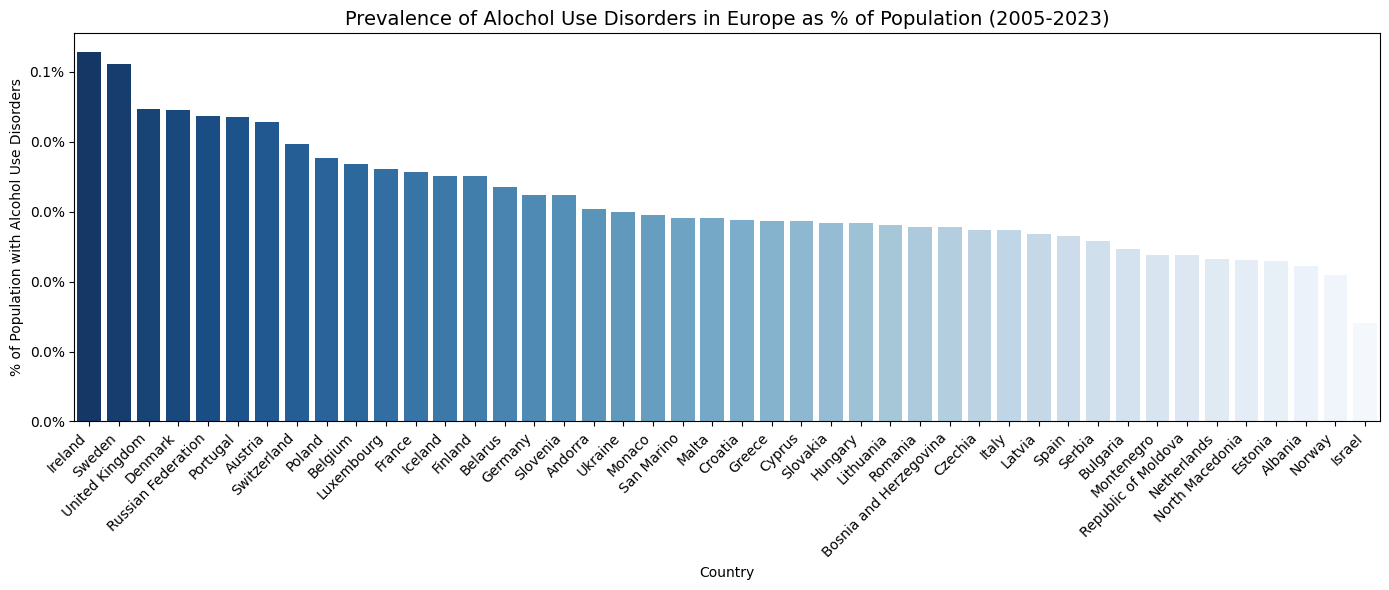

In [89]:
plt.figure(figsize=(14, 6))
sns.barplot(
    data=prev_avg.sort_values('precent_of_prevalence', ascending=False),
    x='location',
    y='precent_of_prevalence',
    palette='Blues_r'
)
plt.title('Prevalence of Alochol Use Disorders in Europe as % of Population (2005-2023)', fontsize=14)
plt.xlabel('Country')
plt.ylabel('% of Population with Alcohol Use Disorders')
plt.xticks(rotation=45, ha='right')                 # angle labels for readability
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
plt.tight_layout()
plt.show()

In [64]:
import numpy as np

In [67]:
import plotly.graph_objects as go

In [68]:
prev_avg['bin'] = pd.cut(prev_avg['precent_of_prevalence'], bins=10).astype(str)

In [70]:
prev_avg.head(1)


,location,precent_of_prevalence,bin
0,Albania,0.022228,"(0.0218, 0.0257]"


In [88]:
fig = px.histogram(
    prev_avg,
    x='precent_of_prevalence',
    nbins=10,
    title='Distribution of Alcohol Use Disorder Prevalence in Europe (2005-2023)',
    labels={'precent_of_prevalence': '% of Population with Alcohol Use Disorders'},
)

fig.update_layout(
   plot_bgcolor='white',
    xaxis=dict(showgrid=False, title='% of Population with Alcohol Use Disorders'),
    yaxis=dict(showgrid=True, gridcolor='lightgrey', title='Number of Countries'),
    bargap=0.05,
    showlegend=False
)

fig.show()

In [87]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [105]:
fig = make_subplots(rows=1, cols=3,
                    subplot_titles=['Distribution of Percentage of Population with Alcohol Use Disorders',
                                    'Liters/Capita Distribution',
                                    'Abstention Rate Distribution'])
fig.add_trace(go.Histogram(x=prev_avg['precent_of_prevalence'], nbinsx=10), row=1, col=1)
fig.add_trace(go.Histogram(x=con_avg['NumericValue'], nbinsx=10), row=1, col=2)
fig.add_trace(go.Histogram(x=df_avg['NumericValue'], nbinsx=10), row=1, col=3)

fig.update_layout(
    title='Distribution of Key variables - European Drinking Patterns',
    plot_bgcolor='white',
    showlegend=False,
    bargap=0.05,
    height=400,
    width=1200
)
fig.update_xaxes(showgrid=False)
fig.update_xaxes(title_text= '% of population with AUD', row=1, col=1)
fig.update_xaxes(title_text='Liters of Pure Alcohol', row=1, col=2)
fig.update_xaxes(title_text='% of abstainers in Population', row=1, col=3)
fig.update_yaxes(showgrid=True, gridcolor='lightgrey', title_text='Count of Countries')



In [ ]:
master_prevalence

array(['Albania', 'Andorra', 'Austria', 'Belarus', 'Belgium',
       'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Cyprus',
       'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany',
       'Greece', 'Hungary', 'Iceland', 'Ireland', 'Israel', 'Italy',
       'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Monaco',
       'Montenegro', 'Netherlands', 'North Macedonia', 'Norway', 'Poland',
       'Portugal', 'Republic of Moldova', 'Romania', 'Russian Federation',
       'San Marino', 'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
       'Switzerland', 'Ukraine', 'United Kingdom'], dtype=object)

In [106]:
master_prevalence.head(1)

,location,sex,age,year,precent_of_prevalence,upper_bound,lower_bound
0,Albania,Male,15-19 years,2005,0.009183,0.014542,0.005085


In [102]:
cluster_df1 = pd.read_csv('/Users/nestocr/Documents/DataAnalytics_BootCamp/da-capstone-project-dayane-ernesto/Ernestos_finds/clusters_with_name.csv')

In [107]:
cluster_df1.head(1)

,location,prevalence,liters/capita,abstention_rate,cluster,cluster_num
0,Albania,0.020138,4.216621,33.654735,Abstainer-Dominant Cultures,0


In [115]:
slope_df = master_prevalence [
    (master_prevalence['year'].isin([2010,2019])) &
    (master_prevalence['age'] == '20-24 years') &
    (master_prevalence['sex']== 'Both Sexes')
].copy()

slope_df = slope_df.merge(cluster_df1[['location','cluster']], on= 'location', how='inner')

pivot_cluster = slope_df.pivot_table(
    index='cluster',
    columns='year',
    values='precent_of_prevalence',
    aggfunc='mean'
)




In [117]:
pivot_cluster

year,2010,2019
cluster,,
Abstainer-Dominant Cultures,0.022709,0.022079
High Consumption Cultures,0.034142,0.031186
High-Risk Drinking Cultures,0.047882,0.043585
Mainstream Drinking Cultures,0.028884,0.025993


In [111]:
import matplotlib.ticker as mticker

(0.0, 0.04917167096833333)

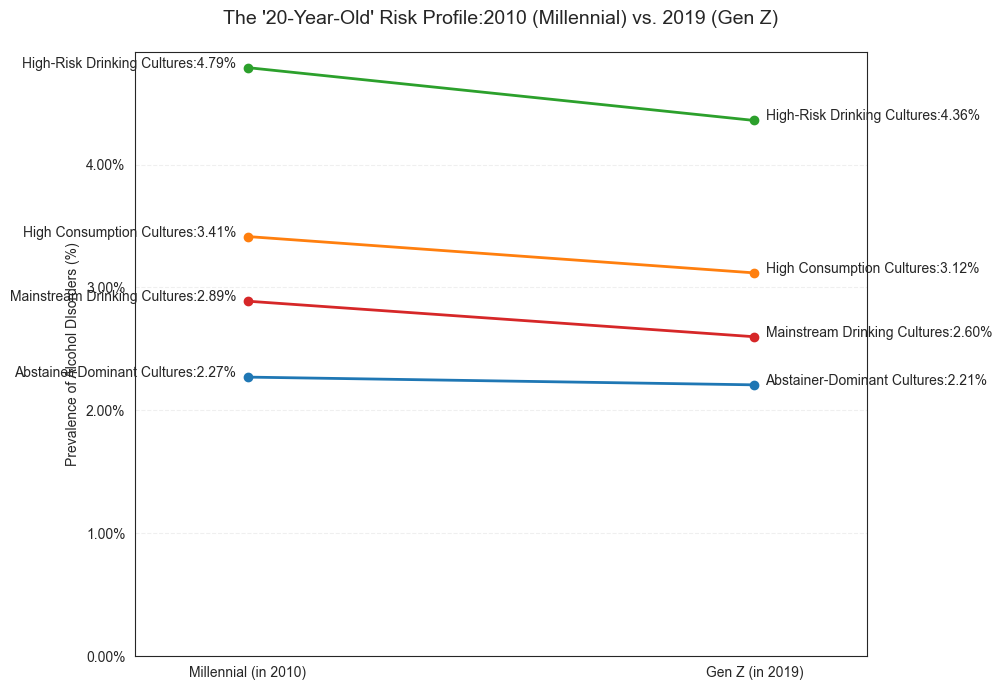

In [118]:
plt.figure(figsize=(10,7))
sns.set_style('white')

for i in pivot_cluster.index:
    plt.plot([2010,2019], [pivot_cluster.loc[i, 2010],pivot_cluster.loc[i, 2019]], marker='o', label = i, linewidth = 2)
    plt.text(2009.8,pivot_cluster.loc[i,2010], f'{i}:{pivot_cluster.loc[i, 2010]*100:.2f}%',horizontalalignment='right', fontsize=10)
    plt.text(2019.2,pivot_cluster.loc[i,2019], f'{i}:{pivot_cluster.loc[i, 2019]*100:.2f}%',horizontalalignment='left', fontsize=10)

plt.title("The '20-Year-Old' Risk Profile:2010 (Millennial) vs. 2019 (Gen Z)",fontsize=14, pad = 20)
plt.ylabel("Prevalence of Alcohol DIsorders (%)")
plt.xticks([2010,2019], ["Millennial (in 2010)", "Gen Z (in 2019)"])
plt.xlim(2008, 2021)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2%}'))
plt.ylim(bottom=0)

In [164]:
fig = go.Figure()

colors = {
    'High-Risk Drinking Cultures': '#2ca02c',
    'High Consumption Cultures': '#ff7f0e',
    'Mainstream Drinking Cultures': '#d62728',
    'Abstainer-Dominant Cultures': '#1f77b4'
}

for cluster in pivot_cluster.index:
    val_2010 = pivot_cluster.loc[cluster, 2010]
    val_2019 = pivot_cluster.loc[cluster, 2019]
    color = colors.get (cluster, 'grey')

    fig.add_trace(go.Scatter(
        x=[2010,2019],
        y=[val_2010, val_2019],
        mode='lines+markers',
        name=cluster,
        line=dict(color=color, width=2.5),
        marker=dict (size=8),
        hovertemplate=f'<b>{cluster}</b><br>Year: %{{x}}<>brPrevalence: %{{y:.2%}}<extra></extra>'
    ))

    fig.add_annotation(
        x=2019, y=val_2019,
        text=f'<br>{val_2019*100:.2f}%',
        xanchor='left',showarrow=False,
        font=dict(size=11, color=color),
        xshift=20
    )
    fig.add_annotation(
        x=2009, y=val_2010,
        text=f'<br>{val_2010*100:.2f}%',
        xanchor='center',showarrow=False,
        font=dict(size=11, color=color),
        

    )
fig.update_layout(
    title=dict(text="The '20-Year-Old' Risk Profile: 2010 (Millennial vs. 2019(Gen Z)", font=dict(size=15)),
    plot_bgcolor='white',
    showlegend=True,
    height=550,
    width=900,
    xaxis=dict(
        tickvals=[2010,2019],
        ticktext=['Millennial (in 2010)', 'Gen Z (in 2019)'],
        showgrid=False,
        range=[2007, 2022]
    ),
    yaxis=dict(
        tickformat='.2%',
        showgrid=True,
        gridcolor='lightgrey',
        gridwidth=1,
        griddash='dash',
        range=[0,0.06]
    ),
    margin=dict(l=95, r=200, t=60, b=60)    
)
fig.show()